In [1]:
import torch 
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import numpy as np
import re
import nltk
nltk.download("punkt_tab")
from nltk.tokenize import sent_tokenize

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/vanessahuo/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
from datasets import load_dataset
ds = load_dataset("a2aj/canadian-case-law")

/opt/miniconda3/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

BCCA/train.parquet:   0%|          | 0.00/186M [00:00<?, ?B/s]

BCSC/train.parquet:   0%|          | 0.00/915M [00:00<?, ?B/s]

...

SCC/train.parquet:   0%|          | 0.00/365M [00:00<?, ?B/s]

SST/train.parquet:   0%|          | 0.00/226M [00:00<?, ?B/s]

TCC/train.parquet:   0%|          | 0.00/205M [00:00<?, ?B/s]

YKCA/train.parquet:   0%|          | 0.00/4.09M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/224086 [00:00<?, ? examples/s]

In [3]:
train = ds["train"]
print(train[0])

{'dataset': 'BCCA', 'citation_en': '2017 BCCA 393', 'citation2_en': '', 'name_en': 'Iser v. Canada (Attorney General)', 'document_date_en': datetime.datetime(2017, 11, 3, 0, 0, tzinfo=<UTC>), 'url_en': 'https://www.bccourts.ca/jdb-txt/ca/17/03/2017BCCA0393.htm', 'scraped_timestamp_en': datetime.datetime(2026, 1, 18, 5, 4, 42, 940000, tzinfo=<UTC>), 'unofficial_text_en': '\n2017 BCCA 393 Iser v. Canada (Attorney General)\nCOURT OF APPEAL FOR BRITISH COLUMBIA\nCitation:\nIser v. Canada (Attorney General),\n2017 BCCA 393\nDate: 20171103\nDockets: CA43705; CA43972; and CA44147\nDockets: CA43705 and CA44147\nBetween:\nChristopher Henry Iser by his committee, Jessica Nicole Iser\nAppellant\n(Plaintiff)\nAnd\nThe Attorney General of Canada, Vince Leblanc, Scott Verwald\nand John Does #1-8\nRespondents\n(Defendants)\n- and -\nDocket: CA43972\nBetween:\nChristopher Henry Iser by his committee, Jessica Nicole Iser\nRespondent\n(Plaintiff)\nAnd\nThe Attorney General of Canada, Vince Leblanc, Scot

In [4]:
print(f"{'Column':<30} {'Non-null':>12} | {'Null':>12} | {'Total':>12} | {'Coverage':>9}")
print("-" * 85)

for col in train.features:
    non_null = sum(x is not None for x in train[col])
    null = len(train) - non_null

    print(
        f"{col:<30} "
        f"{non_null:>12,} | "
        f"{null:>12,} | "
        f"{len(train):>12,} | "
        f"{non_null / len(train) * 100:>8.2f}%"
    )

Column                             Non-null |         Null |        Total |  Coverage
-------------------------------------------------------------------------------------
dataset                             224,086 |            0 |      224,086 |   100.00%
citation_en                         223,253 |          833 |      224,086 |    99.63%
citation2_en                        223,253 |          833 |      224,086 |    99.63%
name_en                             223,253 |          833 |      224,086 |    99.63%
document_date_en                    223,253 |          833 |      224,086 |    99.63%
url_en                              223,253 |          833 |      224,086 |    99.63%
scraped_timestamp_en                223,253 |          833 |      224,086 |    99.63%
unofficial_text_en                  223,253 |          833 |      224,086 |    99.63%
cases_cited_en                      223,208 |          878 |      224,086 |    99.61%
cases_citing_en                     181,371 |       42

In [5]:
# Remove rows with null values in the "unofficial_text_en" column
clean_data = train.filter(
    lambda x: (
        x["unofficial_text_en"] is not None
        and x["unofficial_text_en"].strip() != ""
        and "no document available for this decision" not in x["unofficial_text_en"]
    )
)

# Strip citation/metadata headers to keep only the decision body.
# First matching rule wins; the matched heading line is kept.
# Rule 1: cut at the first reasons heading on its own line (STATEMENT OF
#   REASONS, REASONS FOR DECISION, REASONS AND DECISION, JUDGMENT AND
#   REASONS, Reasons for Judgment, "The judgment of the Court was
#   delivered by", APPEAL BOOK ENDORSEMENT, ...) or at the
#   "Ottawa, <weekday>, <date>" / "Order and reasons issued <weekday>"
#   line that opens a CITT-style formal order. First 60% of the doc only.
# Rule 2: if the document has a "Decision Content" metadata delimiter
#   (SCC, SST, ONCA, ... scrapes), keep everything after it.
# Rule 3: otherwise cut at the first numbered paragraph "[#]" in the
#   first half of the document.
# Rule 4 (RPD): refugee decisions have a bilingual cover page ending with
#   fixed labels (Minister's Counsel / Conseil du ministre, IRB
#   translation notice) - cut after the last such marker in the first 40%
#   of the doc, then skip filler lines (Nil, N/A, XXXXX redactions).
# Rule 5: short decisions where the header is more than half the doc:
#   cut at a late "[#]" only if its line is long prose (>= 120 chars).
#   Footnote lines like "[1] (1980), 41 N.S.R. (2d) 104." are short
#   citations, so this avoids cutting a judgment down to its footnotes.
# Docs matching no rule are kept unchanged.
REASONS_HEAD = re.compile(
    r"^\s*(STATEMENT OF REASONS|REASONS FOR DECISION|REASONS (AND|FOR) DECISIONS?"
    r"|DECISION AND REASONS|JUDGMENT AND REASONS|REASONS FOR JUDGMENT"
    r"|Reasons for Judgment)\s*$"
    r"|^The judgment of the Court was delivered by"
    r"|APPEAL BOOK ENDORSEMENT"  # can be glued mid-line by the scrape
    r"|^Ottawa, (Monday|Tuesday|Wednesday|Thursday|Friday|Saturday|Sunday)"
    r"|^(Order|Orders|Determination|Finding|Decision|Reasons)[^\n]{0,30}issued (Monday|Tuesday|Wednesday|Thursday|Friday|Saturday|Sunday)",
    re.MULTILINE,
)
RPD_COVER = re.compile(
    r"^[^\n]*("
    r"translation\.traduction@irb"
    r"|947-3213"
    r"|MINISTER'?S COUNSEL|Minister'?s Counsel"
    r"|Conseil (de la|du) ministre"
    r"|Agent(\(e\))? des tribunaux"
    r"|Représentant(\(e\))?\(?s?\)? désigné"
    r"|Conseil du (de la )?demandeur"
    r")[^\n]*$",
    re.MULTILINE | re.IGNORECASE,
)
RPD_FILLER = re.compile(r"^\s*(nil|n/a|none|x{3,}[\sx]*)\s*$", re.IGNORECASE)

def strip_header(example):
    text = example["unofficial_text_en"]
    # rule 1: reasons heading / formal order date line. Guard: only cut if
    # no numbered paragraph [#] precedes the heading - otherwise the match
    # is a quoted heading inside the judgment (e.g. lower-court reasons
    # quoted mid-decision) and cutting there would delete real paragraphs.
    m = REASONS_HEAD.search(text)
    if m and m.start() / len(text) < 0.6:
        p = re.search(r"^\[\d+\]", text, re.MULTILINE)
        if p is None or p.start() >= m.start():
            return {"body_text_en": text[m.start():]}
    # rule 2: "Decision Content" delimiter
    m = re.search(r"^Decision Content\s*$", text, re.MULTILINE)
    if m:
        return {"body_text_en": text[m.end():].lstrip("\n")}
    # rule 3: first numbered paragraph in the first half
    m = re.search(r"^\[\d+\]", text, re.MULTILINE)
    if m and m.start() / len(text) < 0.5:
        return {"body_text_en": text[m.start():]}
    # rule 4: RPD cover page
    if example["dataset"] == "RPD":
        last = None
        for cm in RPD_COVER.finditer(text, 0, int(len(text) * 0.4)):
            last = cm
        if last is not None:
            lines = text[last.end():].split("\n")
            k = 0
            while k < len(lines) and (not lines[k].strip() or RPD_FILLER.match(lines[k])):
                k += 1
            return {"body_text_en": "\n".join(lines[k:])}
    # rule 5: late [#] whose line looks like a paragraph, not a footnote
    if m:
        line_end = text.find("\n", m.start())
        line_len = (len(text) if line_end == -1 else line_end) - m.start()
        if line_len >= 120:
            return {"body_text_en": text[m.start():]}
    return {"body_text_en": text}

clean_data = clean_data.map(strip_header)

# Drop documents with 200 words or fewer (inclusive) - too short for QA
# generation. Short cleaned bodies are disposition-only stubs ("The
# appeal was withdrawn", "I agree" concurrences, costs endorsements) with
# no facts or reasoning to ask about; above 200 words they reliably
# contain facts, issue, holding and reasons.
MIN_WORDS = 200
clean_data = clean_data.filter(
    lambda x: len(x["body_text_en"].split()) > MIN_WORDS
)

print(f"{len(clean_data):,} documents after cleaning")
print(clean_data[743]["body_text_en"][:500])

Filter:   0%|          | 0/224086 [00:00<?, ? examples/s]

Map:   0%|          | 0/223009 [00:00<?, ? examples/s]

Filter:   0%|          | 0/223009 [00:00<?, ? examples/s]

217,809 documents after cleaning
[1] This is an appeal from an order dismissing an application for an order compelling Ms. Tran to attend a second independent medical examination ("IME") with Dr. Simon Horlick, an orthopaedic surgeon. At the hearing of the appeal the appeal was allowed and the following order made:
The appeal is allowed and the operative terms of the order of the chambers judge dated January 19, 2018 are varied to read:
1. The defendant's application for an order compelling the plaintiff to attend the offices o


In [6]:
import sqlite3
import json

# Save the filtered + header-stripped data to a SQLite database
cols = [
    "dataset",
    "citation_en",
    "name_en",
    "document_date_en",
    "url_en",
    "body_text_en",
]
df = clean_data.select_columns(cols).to_pandas()
df = df.rename(columns={"body_text_en": "cleaned_unofficial_text_en"})
# SQLite has no timezone-aware datetime type; store dates as ISO strings
df["document_date_en"] = df["document_date_en"].astype(str)

conn = sqlite3.connect("clean_cases.db")
df.to_sql("cases", conn, if_exists="replace", index=True, index_label="doc_id")

n = conn.execute("SELECT COUNT(*) FROM cases").fetchone()[0]
print(f"Saved {n:,} rows to clean_cases.db (table: cases)")
print(conn.execute(
    "SELECT doc_id, citation_en, name_en, substr(cleaned_unofficial_text_en, 1, 80) FROM cases LIMIT 3"
).fetchall())
conn.close()

# Also save the same rows as JSONL, one record per line, doc_id matching the
# sqlite row index above.
jsonl_path = "clean_cases.jsonl"
with open(jsonl_path, "w", encoding="utf-8") as f:
    for doc_id, row in df.iterrows():
        record = {"doc_id": int(doc_id), **row.to_dict()}
        f.write(json.dumps(record, ensure_ascii=False) + "\n")

print(f"Saved {len(df):,} rows to {jsonl_path}")

Saved 217,809 rows to clean_cases.db (table: cases)
[(0, '2017 BCCA 393', 'Iser v. Canada (Attorney General)', '[1] GROBERMAN J.A.: These are appeals, with leave, from judgments of the Supreme'), (1, '2017 BCCA 392', 'Cambie Surgeries Corporation v. British Columbia (Attorney General)', '[1] In Cambie Surgeries Corporation v. British Columbia (Attorney General), 2017'), (2, '2017 BCCA 391', 'Gallant v. Houde', '[1] FRANKEL J.A.: The appellant, Daniel Gallant and the respondent Jeanne Houde,')]
Saved 217,809 rows to clean_cases.jsonl


In [7]:
char_count = []
word_count = []
sentences_count = []
paragraph_count = []
for text in clean_data["body_text_en"]:
    char_count.append(len(text))
    word_count.append(len(text.split()))
    sentences_count.append(len(sent_tokenize(text)))
    # count officially numbered paragraphs ([1], [2], ...) at line starts
    paragraph_count.append(len(re.findall(r"^\[\d+\]", text, re.MULTILINE)))

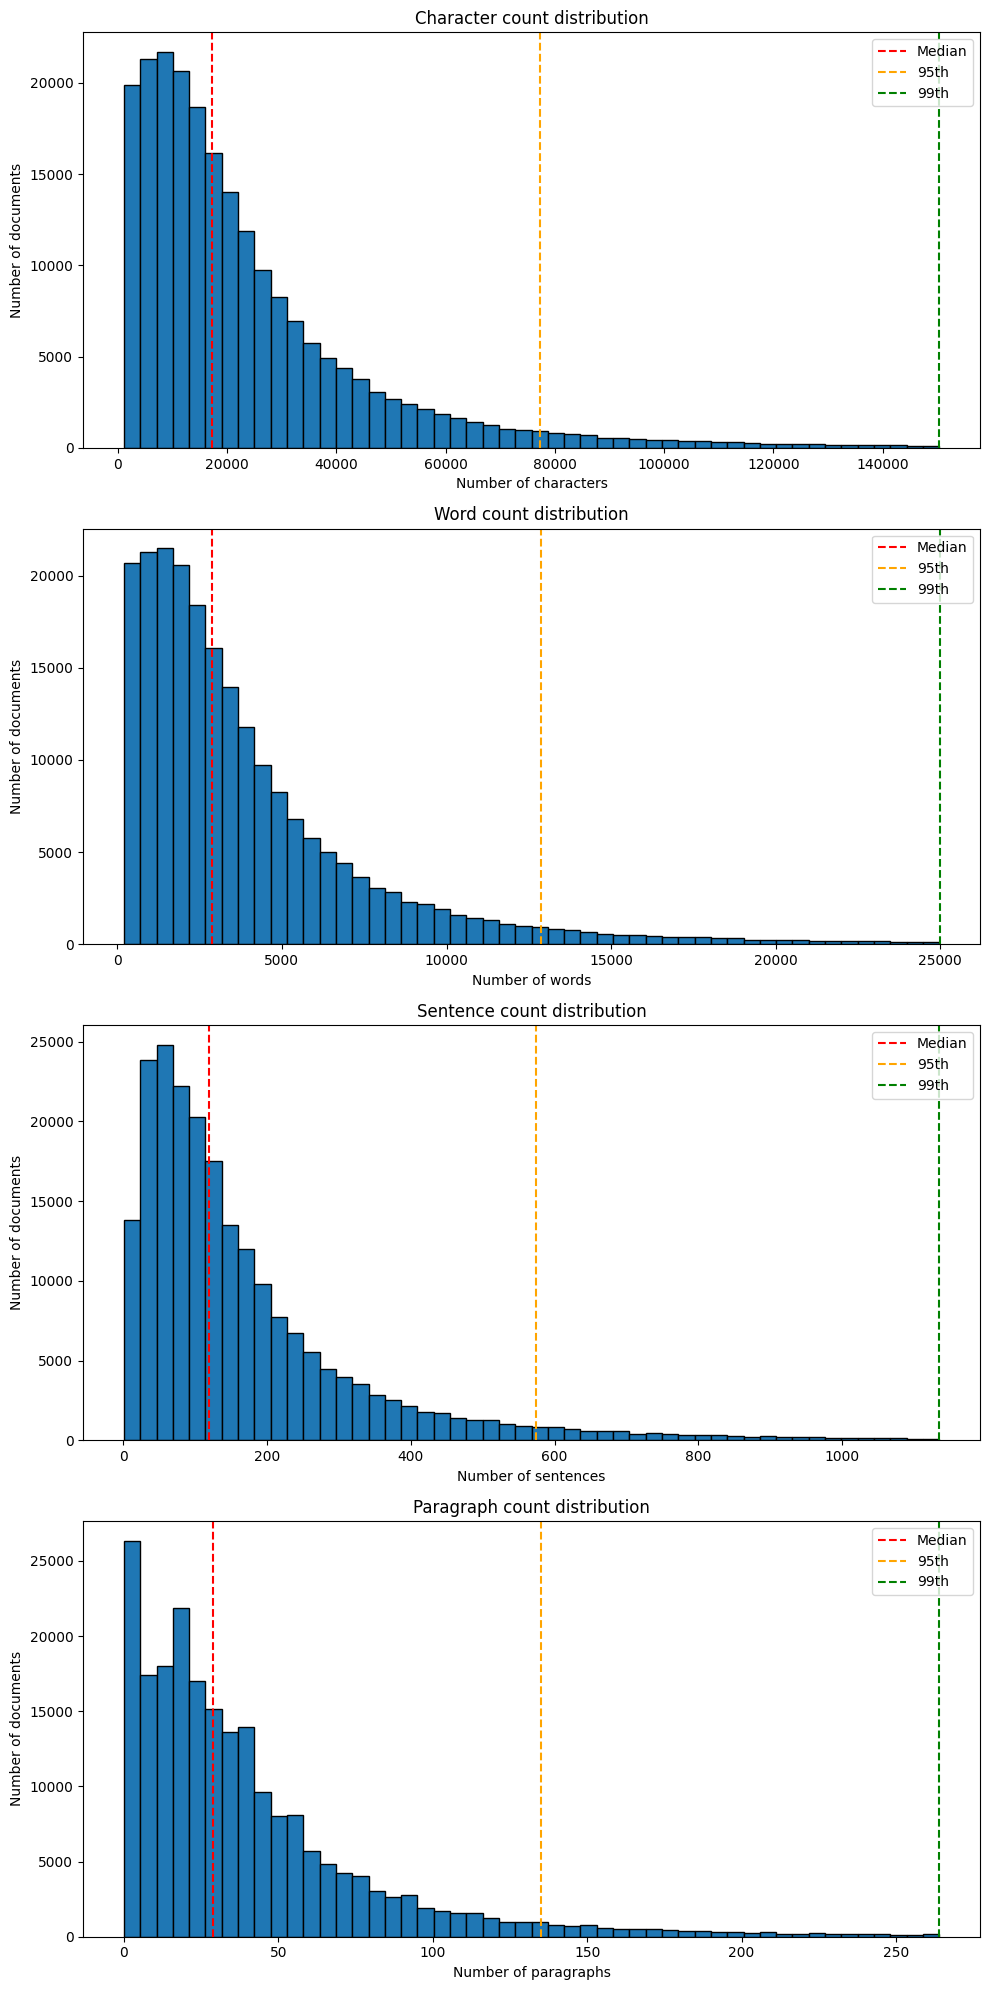

In [8]:
fig, axes = plt.subplots(4, 1, figsize=(10, 20))

plots = [
    (char_count, "Number of characters", "Character count distribution"),
    (word_count, "Number of words", "Word count distribution"),
    (sentences_count, "Number of sentences", "Sentence count distribution"),
    (paragraph_count, "Number of paragraphs", "Paragraph count distribution"),
]

for ax, (data, xlabel, title) in zip(axes, plots):
    p99 = np.percentile(data, 99)
    ax.hist(
        [x for x in data if x <= p99],
        bins=50,
        edgecolor="black"
    )

    ax.axvline(np.median(data), color="red", linestyle="--", label="Median")
    ax.axvline(np.percentile(data, 95), color="orange", linestyle="--", label="95th")
    ax.axvline(p99, color="green", linestyle="--", label="99th")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Number of documents")
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

In [9]:
max_indices = np.argsort(char_count)[0:-1] 
print(f"Document with the most characters (index {max_indices[-1]}):") 
print(clean_data[max_indices[-3]]["body_text_en"])

Document with the most characters (index 32294):
Reasons for Judgment
Counsel for the Plaintiffs:
D. M. Robbins
D. M. Rosenberg, K.C.
A. G. Murphy
J. A. Proudfoot
P. W. Jones
I. A. Kennedy
F. P. De Luca
J. T. Riddell
J. L. Karras
A. M. Mendelson
B. R. Martin
A. C. Giannelia
J. Boutin
R. J. Garrett
T. Kolawole
C. C. Charlie
L. E. Harris
S. A. Morgan
D. J. Larkin
M. D. Boulton
M. B. Bendle
M. A. Berlin
K. Lindsay
M. E. Turpel-Lafond
E. Smyth A/S
Counsel for the Defendant
Attorney General of Canada:
S.-L. Vigneau
B. C. Marleau
M. L. French
L.M.G. Nevens
M. Bulmer
J. Minkley
M. Frey
P. Cassidy
J. E. Tross
G. L. Angrove
J. A. Rosenthal
M. P. Seebaran
K. L. Boyer
W. Watson
A. G. Dewitt
M. E. Tessier
M. Morawski
Counsel for the Defendant
His Majesty the King in right of
the Province of British Columbia:
K. B. Bergner
G. R. Thompson
K. Phillips
M.-S. Poulin
M. F. Volk
R. L. Dickinson
D.K.B. Dempster
A. D. Cochran
C.A.M. Jarawka
N.C.C. Healey
J. S. Andrews
Counsel for the Defendant
City of Rich

In [10]:
for i in range(1, 1000, 1):
    min_indices = np.argsort(word_count)[0:i]
    print("Words:", word_count[min_indices[-1]])
    print(f"Document with the fewest characters (index {min_indices[-1]}):")
    print(clean_data[min_indices[-1]]["body_text_en"])

Words: 201
Document with the fewest characters (index 68345):
PR-2007-078 _ CITT - Procurement - Determinations - NETGEAR, INC.
NETGEAR, INC.
Determinations
NETGEAR, INC. File No. PR-2007-078
TABLE OF CONTENTS
BY FACSIMILE
January 23, 2008
___________________ ___________________ ___________________ ___________________ ___________________ ___________________
-and-
___________________ ___________________ ___________________ ___________________ ___________________ ___________________
___________________:
Re:
Solicitation Number EN869-060292/D (RVD142) (File No. PR-2007-078) NETGEAR, Inc.
The Tribunal is in receipt of the Department of Public Works and Government Services’ letter dated January 14, 2008, in which it advises that solicitation number EN869-060292/D has been cancelled.
According to paragraph 7(1)(b) of the Canadian International Trade Tribunal Procurement Inquiry Regulations (Regulations), the complaint must be in respect of a “designated contract”, which is defined in the Can

In [11]:
count = sum(
    "Subject\n" in text
    for text in clean_data["unofficial_text_en"]
)

print(count)


20757


In [12]:
print(len(clean_data))

217809


In [13]:
import sqlite3
import pandas as pd

# Connect to the database
conn = sqlite3.connect("clean_cases.db")

# List all tables
tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

print("Tables:")
print(tables)

Tables:
    name
0  cases
